In [ ]:
import pandas as pd
from google.colab import files

import numpy as np

from sklearn.impute import KNNImputer

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==============================
# Paso 1: Cargar datos en Colab
# ==============================

uploaded = files.upload()

file_names = list(uploaded.keys())
print("Archivos subidos:", file_names)

dfs = {}
for fname in file_names:
    if fname.endswith(".csv"):
        dfs[fname] = pd.read_csv(fname)
    else:
        dfs[fname] = pd.read_excel(fname)

for fname, df in dfs.items():
    print(f"\n=== {fname} ===")
    print("Dimensiones:", df.shape)
    display(df.head())


Archivos subidos: []


In [ ]:
# ==============================
# Paso 2: Inspección inicial
# ==============================

for fname, df in dfs.items():
    print(f"\n=== {fname} ===")
    print("Columnas:", df.columns.tolist())
    print("\nInformación del DataFrame:")
    print(df.info())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("="*50)


=== precios-inmobiliarios-bd-desagregada-venta-2025-2.xlsx ===
Columnas: ['Unnamed: 0', 'Año', 'Trimestre', 'Precio en dólares corrientes', 'Tipo de cambio', 'IPC', 'Precio en soles corrientes', 'Precio en soles constantes de 2009', 'Distrito', 'Superficie ', 'Número de habitaciones', 'Número de baños', 'Número de garajes', 'Piso de ubicación', 'Vista al exterior', 'Años de antigüedad']

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112655 entries, 0 to 112654
Data columns (total 16 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Unnamed: 0                          112655 non-null  object 
 1   Año                                 112655 non-null  int64  
 2   Trimestre                           112655 non-null  int64  
 3   Precio en dólares corrientes        112655 non-null  float64
 4   Tipo de cambio                      112655 non-null  float64
 5   IPC

In [ ]:
# =======================================
# Limpieza inicial de columnas y datos
# =======================================

df = pd.read_excel("precios-inmobiliarios-bd-desagregada-venta-2025-2.xlsx")

# --- Renombrar columnas clave para estandarizar ---
rename_map = {
    'Año': 'anio',
    'Trimestre': 'trimestre',
    'Precio en dólares corrientes': 'precio_usd',
    'Tipo de cambio': 'tipo_cambio',
    'IPC': 'ipc',
    'Precio en soles corrientes': 'precio_soles_corrientes',
    'Precio en soles constantes de 2009': 'precio_target',
    'Distrito': 'distrito',
    'Superficie': 'superficie',
    'Número de habitaciones': 'habitaciones',
    'Número de baños': 'banos',
    'Número de garajes': 'garajes',
    'Piso de ubicación': 'piso',
    'Vista al exterior': 'vista_exterior',
    'Años de antigüedad': 'antiguedad'
}
df = df.rename(columns=rename_map)

cols_drop = ['Unnamed: 0', 'trimestre']
df = df.drop(columns=[c for c in cols_drop if c in df.columns], errors='ignore')

if 'vista_exterior' in df.columns:
    df['vista_exterior'] = pd.to_numeric(df['vista_exterior'], errors='coerce')
    df['vista_exterior'] = df['vista_exterior'].apply(
        lambda x: 1 if pd.notnull(x) and x > 0 else (0 if pd.notnull(x) and x == 0 else np.nan)
    )

df = df[(df['anio'] >= 2018) & (df['anio'] <= 2025)].copy()
df = df.reset_index(drop=True)

# --- Mostrar resumen ---
print("Dimensiones finales del dataset limpio:", df.shape)
print("\nColumnas finales:")
print(df.columns.tolist())
print("\nRango temporal (Año):", df['anio'].min(), "→", df['anio'].max())
print("\nVista previa:")
display(df.head())


Dimensiones finales del dataset limpio: (55875, 14)

Columnas finales:
['anio', 'precio_usd', 'tipo_cambio', 'ipc', 'precio_soles_corrientes', 'precio_target', 'distrito', 'Superficie ', 'habitaciones', 'banos', 'garajes', 'piso', 'vista_exterior', 'antiguedad']

Rango temporal (Año): 2018 → 2025

Vista previa:


,anio,precio_usd,tipo_cambio,ipc,precio_soles_corrientes,precio_target,distrito,Superficie,habitaciones,banos,garajes,piso,vista_exterior,antiguedad
0,2018,134000.0,3.238481,128.013993,433956.394444,338991.373634,Bellavista,94.0,3.0,2.5,0.0,3.0,1.0,0.0
1,2018,60000.0,3.238481,128.013993,194308.833333,151787.182224,Bellavista,60.0,2.0,1.0,1.0,5.0,1.0,20.0
2,2018,83000.0,3.238481,128.013993,268793.886111,209972.268743,Bellavista,85.0,3.0,1.0,0.0,5.0,1.0,20.0
3,2018,85000.0,3.238481,128.013993,275270.847222,215031.841484,Bellavista,88.0,2.0,1.0,0.0,2.0,0.0,10.0
4,2018,80000.0,3.238481,128.013993,259078.444444,202382.909632,Bellavista,87.0,3.0,2.0,1.0,4.0,1.0,0.0


In [ ]:
print("\nInformación del DataFrame:")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("="*50)


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55875 entries, 0 to 55874
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anio                     55875 non-null  int64  
 1   precio_usd               55875 non-null  float64
 2   tipo_cambio              55875 non-null  float64
 3   ipc                      55875 non-null  float64
 4   precio_soles_corrientes  55875 non-null  float64
 5   precio_target            55875 non-null  float64
 6   distrito                 55875 non-null  object 
 7   Superficie               55875 non-null  float64
 8   habitaciones             55862 non-null  float64
 9   banos                    55839 non-null  float64
 10  garajes                  54331 non-null  float64
 11  piso                     51457 non-null  float64
 12  vista_exterior           51843 non-null  float64
 13  antiguedad               54153 non-null  float64

In [ ]:
df_nulls = df[df.isnull().any(axis=1)]
print("Filas con al menos un valor nulo:", df_nulls.shape[0])
display(df_nulls.head(10))

Filas con al menos un valor nulo: 7369


,anio,precio_usd,tipo_cambio,ipc,precio_soles_corrientes,precio_target,distrito,Superficie,habitaciones,banos,garajes,piso,vista_exterior,antiguedad
924,2018,120000.0,3.238481,128.013993,388617.666667,303574.364448,Pueblo Libre,77.69,3.0,2.0,NaN,0.0,1.0,15.0
1096,2018,164832.0,3.258396,128.518374,537087.964436,417907.531600,Bellavista,172.60,4.0,5.0,1.0,NaN,1.0,5.0
1117,2018,98000.0,3.258396,128.518374,319322.828788,248464.728310,Breña,85.00,3.0,2.0,0.0,NaN,1.0,30.0
1125,2018,72500.0,3.258396,128.518374,236233.725379,183813.191862,Breña,100.00,2.0,1.0,1.0,NaN,1.0,10.0
1131,2018,34000.0,3.258396,128.518374,110785.471212,86202.048597,Breña,41.92,1.0,1.0,0.0,NaN,1.0,50.0
1179,2018,65000.0,3.258396,128.518374,211795.753788,164798.034083,Cercado de Lima,99.00,2.0,1.0,0.0,NaN,1.0,18.0
1185,2018,126086.0,3.258396,128.518374,410838.144802,319672.691160,Cercado de Lima,73.00,3.0,2.0,0.0,NaN,1.0,0.0
1192,2018,80122.0,3.258396,128.518374,261069.221308,203137.662874,Cercado de Lima,65.00,3.0,2.0,0.0,NaN,1.0,0.0
1193,2018,65000.0,3.258396,128.518374,211795.753788,164798.034083,Cercado de Lima,50.00,1.0,1.0,0.0,NaN,1.0,30.0
1195,2018,78900.0,3.258396,128.518374,257087.461136,200039.459833,Cercado de Lima,58.17,3.0,2.0,0.0,NaN,1.0,2.0


In [ ]:
df[df['garajes'].isnull()].head(10)

,anio,precio_usd,tipo_cambio,ipc,precio_soles_corrientes,precio_target,distrito,Superficie,habitaciones,banos,garajes,piso,vista_exterior,antiguedad
924,2018,120000.0,3.238481,128.013993,388617.666667,303574.364448,Pueblo Libre,77.69,3.0,2.0,NaN,0.0,1.0,15.0
2227,2018,76000.0,3.291997,129.501577,250191.788889,193195.939914,Cercado de Lima,65.29,2.0,2.0,NaN,12.0,1.0,1.0
2228,2018,85000.0,3.291997,129.501577,279819.763889,216074.406483,Cercado de Lima,77.00,2.0,1.0,NaN,1.0,1.0,12.0
2269,2018,66000.0,3.291997,129.501577,217271.816667,167775.421504,Chorrillos,57.60,3.0,2.0,NaN,7.0,1.0,4.0
2330,2018,58000.0,3.291997,129.501577,190935.838889,147439.006777,Los Olivos,56.00,2.0,1.0,NaN,3.0,1.0,12.0
2376,2018,94000.0,3.291997,129.501577,309447.738889,238952.873052,La Molina,67.00,3.0,1.0,NaN,2.0,1.0,19.0
2377,2018,103000.0,3.291997,129.501577,339075.713889,261831.339621,La Molina,88.00,3.0,2.0,NaN,3.0,1.0,0.0
2379,2018,65000.0,3.291997,129.501577,213979.819444,165233.369663,La Molina,70.00,2.0,1.0,NaN,1.0,1.0,NaN
2382,2018,159000.0,3.291997,129.501577,523427.558333,404186.242715,La Molina,96.00,3.0,2.0,NaN,2.0,1.0,11.0
2386,2018,95000.0,3.291997,129.501577,312739.736111,241494.924893,La Molina,80.00,2.0,2.0,NaN,NaN,1.0,30.0


In [ ]:
# resumen missing
cols = ['habitaciones','banos','garajes','piso','vista_exterior','antiguedad']
missing_pct = df[cols].isnull().mean()*100
print(missing_pct.sort_values())

habitaciones      0.023266
banos             0.064430
garajes           2.763311
antiguedad        3.081879
vista_exterior    7.216107
piso              7.906935
dtype: float64


In [ ]:
# ver conteos
print(df['garajes'].value_counts(dropna=False).head(20))
print(df['vista_exterior'].value_counts(dropna=False))
print(df['habitaciones'].value_counts(dropna=False).head(20))
print(df['banos'].value_counts(dropna=False).head(20))
print(df['antiguedad'].value_counts(dropna=False).head(20))
print(df['piso'].value_counts(dropna=False).head(20))

garajes
1.0    24895
0.0    21007
2.0     7938
NaN     1544
3.0      367
4.0       94
5.0       30
Name: count, dtype: int64
vista_exterior
1.0    51621
NaN     4032
0.0      222
Name: count, dtype: int64
habitaciones
3.0    33540
2.0    16383
1.0     3551
4.0     2171
5.0      174
6.0       28
NaN       13
7.0       11
8.0        3
9.0        1
Name: count, dtype: int64
banos
2.0    33193
1.0    11675
3.0     9519
4.0     1283
5.0      145
NaN       36
2.5       11
7.0        4
6.0        3
8.0        2
4.5        1
3.5        1
1.5        1
9.0        1
Name: count, dtype: int64
antiguedad
0.0     8314
10.0    3956
5.0     3158
8.0     2473
7.0     2340
15.0    2281
4.0     2251
6.0     2237
3.0     2233
1.0     2167
2.0     1995
20.0    1960
12.0    1952
9.0     1741
NaN     1722
11.0    1246
13.0    1175
14.0    1080
30.0    1074
25.0     911
Name: count, dtype: int64
piso
0.0     48002
NaN      4418
3.0       705
2.0       692
1.0       598
4.0       400
5.0       278
6.0       17

In [ ]:
# ==============================
# Imputación simple
# ==============================

# Crear flags de missing
df['habitaciones_missing'] = df['habitaciones'].isnull().astype(int)
df['banos_missing'] = df['banos'].isnull().astype(int)

# Imputar con la mediana
df['habitaciones'] = df['habitaciones'].fillna(df['habitaciones'].median())
df['banos'] = df['banos'].fillna(df['banos'].median())

# Verificar
print("Valores nulos restantes en habitaciones:", df['habitaciones'].isnull().sum())
print("Valores nulos restantes en banos:", df['banos'].isnull().sum())

print("\nDistribución final de habitaciones:")
print(df['habitaciones'].value_counts().sort_index())

print("\nDistribución final de baños:")
print(df['banos'].value_counts().sort_index())

print("\nEjemplo de flags:")
print(df[['habitaciones','habitaciones_missing','banos','banos_missing']].head(10))


Valores nulos restantes en habitaciones: 0
Valores nulos restantes en banos: 0

Distribución final de habitaciones:
habitaciones
1.0     3551
2.0    16383
3.0    33553
4.0     2171
5.0      174
6.0       28
7.0       11
8.0        3
9.0        1
Name: count, dtype: int64

Distribución final de baños:
banos
1.0    11675
1.5        1
2.0    33229
2.5       11
3.0     9519
3.5        1
4.0     1283
4.5        1
5.0      145
6.0        3
7.0        4
8.0        2
9.0        1
Name: count, dtype: int64

Ejemplo de flags:
   habitaciones  habitaciones_missing  banos  banos_missing
0           3.0                     0    2.5              0
1           2.0                     0    1.0              0
2           3.0                     0    1.0              0
3           2.0                     0    1.0              0
4           3.0                     0    2.0              0
5           3.0                     0    2.0              0
6           2.0                     0    2.0              

In [ ]:
# Normalizar columnas: quitar espacios y pasarlas a minúscula
df.columns = df.columns.str.strip().str.lower()

# Verifica los nombres exactos
print(df.columns.tolist())

['anio', 'precio_usd', 'tipo_cambio', 'ipc', 'precio_soles_corrientes', 'precio_target', 'distrito', 'superficie', 'habitaciones', 'banos', 'garajes', 'piso', 'vista_exterior', 'antiguedad', 'habitaciones_missing', 'banos_missing', 'garajes_missing', 'antiguedad_missing', 'piso_missing', 'vista_exterior_missing']


In [ ]:
# ==============================
# Imputación moderada/alta
# ==============================

# 1. Crear flags de missing
df['garajes_missing'] = df['garajes'].isnull().astype(int)
df['antiguedad_missing'] = df['antiguedad'].isnull().astype(int)
df['piso_missing'] = df['piso'].isnull().astype(int)
df['vista_exterior_missing'] = df['vista_exterior'].isnull().astype(int)

# 2. Definir variables para KNNImputer
cols_knn = ['garajes','antiguedad','piso','superficie','precio_target','habitaciones','banos']
knn_data = df[cols_knn]

# 3. Aplicar KNNImputer (k=5)
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_data)

# 4. Reemplazar en df
df[['garajes','antiguedad','piso']] = knn_imputed[:, [0,1,2]]

# 5. Tratar vista_exterior como ternaria (0,1,-1)
df['vista_exterior'] = df['vista_exterior'].fillna(-1).astype(int)

# 6. Verificar resultados
print("Nulos restantes en columnas imputadas:")
print(df[['garajes','antiguedad','piso','vista_exterior']].isnull().sum())
print("\nDistribución de garajes después de imputación:")
print(df['garajes'].value_counts().sort_index())

print("\nDistribución de antiguedad después de imputación:")
print(df['antiguedad'].value_counts().head(20))

print("\nDistribución de piso después de imputación:")
print(df['piso'].value_counts().sort_index().head(20))

print("\nDistribución de vista_exterior después de imputación:")
print(df['vista_exterior'].value_counts())

Nulos restantes en columnas imputadas:
garajes           0
antiguedad        0
piso              0
vista_exterior    0
dtype: int64

Distribución de garajes después de imputación:
garajes
0.0    21197
0.2      245
0.4      245
0.6      248
0.8      210
1.0    25087
1.2       99
1.4       45
1.6       38
1.8       20
2.0     7944
2.2        5
3.0      368
4.0       94
5.0       30
Name: count, dtype: int64

Distribución de antiguedad después de imputación:
antiguedad
0.0     8315
10.0    3985
5.0     3170
8.0     2492
7.0     2366
15.0    2299
4.0     2263
6.0     2262
3.0     2242
1.0     2169
2.0     2003
12.0    1981
20.0    1963
9.0     1765
11.0    1264
13.0    1197
14.0    1099
30.0    1074
25.0     916
18.0     890
Name: count, dtype: int64

Distribución de piso después de imputación:
piso
0.0    51143
0.2      115
0.4      148
0.6      115
0.8      107
1.0      733
1.2       83
1.4       78
1.6       44
1.8       34
2.0      736
2.2       25
2.4       23
2.6       55
2.8       2

In [ ]:
# Redondear variables categóricas/enteras después del KNNImputer
df['garajes'] = df['garajes'].round().astype(int)
df['antiguedad'] = df['antiguedad'].round().astype(int)
df['piso'] = df['piso'].round().astype(int)


In [ ]:
print("\nInformación del DataFrame:")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("="*50)


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55875 entries, 0 to 55874
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anio                     55875 non-null  int64  
 1   precio_usd               55875 non-null  float64
 2   tipo_cambio              55875 non-null  float64
 3   ipc                      55875 non-null  float64
 4   precio_soles_corrientes  55875 non-null  float64
 5   precio_target            55875 non-null  float64
 6   distrito                 55875 non-null  object 
 7   superficie               55875 non-null  float64
 8   habitaciones             55875 non-null  float64
 9   banos                    55875 non-null  float64
 10  garajes                  55875 non-null  int64  
 11  piso                     55875 non-null  int64  
 12  vista_exterior           55875 non-null  int64  
 13  antiguedad               55875 non-null  int64  

In [ ]:
# Eliminar todas las columnas que terminan en "_missing"
df = df.drop(columns=[col for col in df.columns if col.endswith('_missing')])

print("Columnas finales después de eliminar flags:")
print(df.columns.tolist())


Columnas finales después de eliminar flags:
['anio', 'precio_usd', 'tipo_cambio', 'ipc', 'precio_soles_corrientes', 'precio_target', 'distrito', 'superficie', 'habitaciones', 'banos', 'garajes', 'piso', 'vista_exterior', 'antiguedad']


In [ ]:
print("\nInformación del DataFrame:")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("="*50)

df.head()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55875 entries, 0 to 55874
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anio                     55875 non-null  int64  
 1   precio_usd               55875 non-null  float64
 2   tipo_cambio              55875 non-null  float64
 3   ipc                      55875 non-null  float64
 4   precio_soles_corrientes  55875 non-null  float64
 5   precio_target            55875 non-null  float64
 6   distrito                 55875 non-null  object 
 7   superficie               55875 non-null  float64
 8   habitaciones             55875 non-null  float64
 9   banos                    55875 non-null  float64
 10  garajes                  55875 non-null  int64  
 11  piso                     55875 non-null  int64  
 12  vista_exterior           55875 non-null  int64  
 13  antiguedad               55875 non-null  int64  

,anio,precio_usd,tipo_cambio,ipc,precio_soles_corrientes,precio_target,distrito,superficie,habitaciones,banos,garajes,piso,vista_exterior,antiguedad
0,2018,134000.0,3.238481,128.013993,433956.394444,338991.373634,Bellavista,94.0,3.0,2.5,0,3,1,0
1,2018,60000.0,3.238481,128.013993,194308.833333,151787.182224,Bellavista,60.0,2.0,1.0,1,5,1,20
2,2018,83000.0,3.238481,128.013993,268793.886111,209972.268743,Bellavista,85.0,3.0,1.0,0,5,1,20
3,2018,85000.0,3.238481,128.013993,275270.847222,215031.841484,Bellavista,88.0,2.0,1.0,0,2,0,10
4,2018,80000.0,3.238481,128.013993,259078.444444,202382.909632,Bellavista,87.0,3.0,2.0,1,4,1,0


In [ ]:
# Guardar en CSV
df.to_csv("venta_cleaned.csv", index=False)

# Descargar
files.download("venta_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv("venta_cleaned.csv")

Filas con superficie <= 0: 0
Forma del df después de filtrar superficie: (55875, 14)

--- Filtro de Outliers (basado en precio_m2_usd) ---
Límite inferior (P01) en USD/m²: 666.67
Límite superior (P99) en USD/m²: 3,211.11
Forma original (antes de filtrar outliers): (55875, 15)
Forma final (después de filtrar outliers): (54770, 15)

--- Variables para Interpretación y Modelo creadas ---

Resumen precio_m2_usd (Para Interpretación):
count    54770.000000
mean      1715.556078
std        493.870218
min        666.666667
5%         955.056180
50%       1691.053846
95%       2600.000000
max       3211.111111
Name: precio_m2_usd, dtype: float64

Resumen precio_m2_target (Para Análisis de Correlación):
count    54770.000000
mean      4213.379436
std       1245.815317
min       1499.621735
5%        2313.465834
50%       4130.949908
95%       6443.834287
max       9196.808276
Name: precio_m2_target, dtype: float64

Resumen log_precio (Variable Target del Modelo):
count    54770.000000
mean     

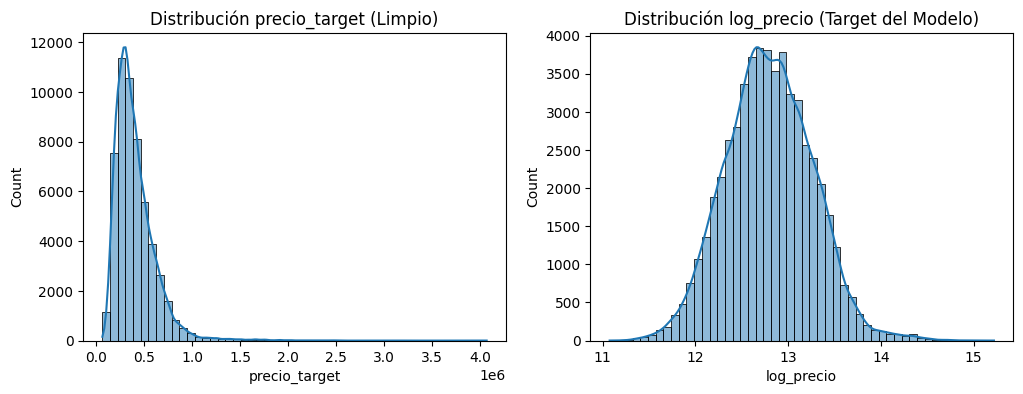

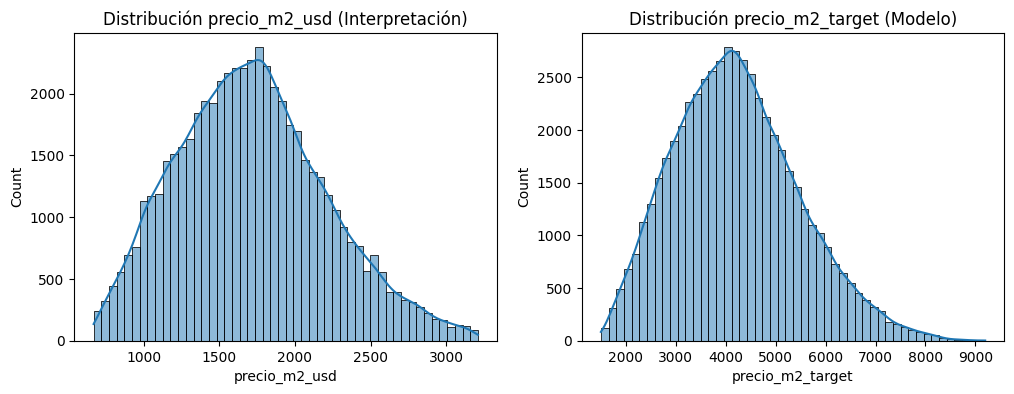


Archivo final 'venta_processed.csv' guardado (con outliers filtrados y todas las variables).


In [ ]:
# =================================================================
# Procesamiento adicional: Filtro de Outliers y Creación de Logs
# (Implementa la recomendación del experto y la solución híbrida)
# =================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Filtrar superficies inválidas (como ya tenías)
print(f"Filas con superficie <= 0: {(df['superficie'] <= 0).sum()}")
df = df[df['superficie'] > 0].copy()
print(f"Forma del df después de filtrar superficie: {df.shape}")

# 2) Paso 2.A: Crear 'precio_m2_usd' para filtrar outliers (Petición del Experto)
# Esta variable es para la INTERPRETACIÓN y el FILTRADO
df['precio_m2_usd'] = df['precio_usd'] / df['superficie']

# 3) Paso 2.B: Filtrar Outliers (Petición del Experto)
# Calculamos percentiles sobre la variable interpretable (USD)
p01 = df['precio_m2_usd'].quantile(0.01)
p99 = df['precio_m2_usd'].quantile(0.99)

print("\n--- Filtro de Outliers (basado en precio_m2_usd) ---")
print(f"Límite inferior (P01) en USD/m²: {p01:,.2f}")
print(f"Límite superior (P99) en USD/m²: {p99:,.2f}")
print(f"Forma original (antes de filtrar outliers): {df.shape}")

# Aplicamos el filtro
df = df[(df['precio_m2_usd'] >= p01) & (df['precio_m2_usd'] <= p99)].copy()
print(f"Forma final (después de filtrar outliers): {df.shape}")

# 4) Paso 2.C: Crear variables del MODELO sobre el df LIMPIO
# Estas variables son para el ENTRENAMIENTO
df['precio_m2_target'] = df['precio_target'] / df['superficie']
df['log_precio'] = np.log1p(df['precio_target'])
df['log_precio_m2'] = np.log1p(df['precio_m2_target'])

print("\n--- Variables para Interpretación y Modelo creadas ---")

# 5) Estadísticos básicos (sobre el df FILTRADO)
print("\nResumen precio_m2_usd (Para Interpretación):")
print(df['precio_m2_usd'].describe(percentiles=[0.05, 0.5, 0.95]))

print("\nResumen precio_m2_target (Para Análisis de Correlación):")
print(df['precio_m2_target'].describe(percentiles=[0.05, 0.5, 0.95]))

print("\nResumen log_precio (Variable Target del Modelo):")
print(df['log_precio'].describe(percentiles=[0.05, 0.5, 0.95]))

# 6) Visualización (sobre el df FILTRADO)
# (Mostramos las variables finales que usaremos)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['precio_target'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribución precio_target (Limpio)")
sns.histplot(df['log_precio'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribución log_precio (Target del Modelo)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['precio_m2_usd'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribución precio_m2_usd (Interpretación)")
sns.histplot(df['precio_m2_target'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribución precio_m2_target (Modelo)")
plt.show()

# 7) Guardar dataset procesado
df.to_csv("venta_processed.csv", index=False)
print("\nArchivo final 'venta_processed.csv' guardado (con outliers filtrados y todas las variables).")

In [ ]:
df = pd.read_csv("venta_processed.csv")

In [ ]:
print("\n--- Ejecutando One-Hot Encoding (OHE) para 'distrito' ---")

# Guardar la forma original para comparar
shape_antes_ohe = df.shape

# 1. Aplicar pd.get_dummies
# drop_first=True es importante para los modelos de regresión
df_encoded = pd.get_dummies(df, columns=['distrito'], prefix='distrito', drop_first=True, dtype=int)

# 2. Asignar de nuevo al DataFrame principal
df = df_encoded.copy()

print(f"Forma original: {shape_antes_ohe}")
print(f"Forma nueva después de OHE: {df.shape}")
print(f"Se crearon {df.shape[1] - shape_antes_ohe[1]} nuevas columnas 'distrito_...'")

# 3. Ver un ejemplo de las nuevas columnas
print("\nEjemplo de las primeras filas con columnas OHE:")
# Filtramos para ver solo algunas de las nuevas columnas
columnas_ejemplo = ['log_precio'] + [col for col in df.columns if 'distrito_' in col][:3]
print(df[columnas_ejemplo].head())


--- Ejecutando One-Hot Encoding (OHE) para 'distrito' ---
Forma original: (54770, 18)
Forma nueva después de OHE: (54770, 38)
Se crearon 20 nuevas columnas 'distrito_...'

Ejemplo de las primeras filas con columnas OHE:
   log_precio  distrito_Barranco  distrito_Bellavista  distrito_Breña
0   12.733733                  0                    1               0
1   11.930241                  0                    1               0
2   12.254736                  0                    1               0
3   12.278546                  0                    1               0
4   12.217922                  0                    1               0



--- Creando 'log_superficie' ---
Variable 'log_superficie' creada.

Comparación de 'superficie' vs 'log_superficie' (Estadísticos):
         superficie  log_superficie
count  54770.000000    54770.000000
mean      94.194526        4.507298
std       32.226766        0.306034
min       24.000000        3.218876
25%       73.000000        4.304065
50%       89.000000        4.499810
75%      111.000000        4.718499
max      560.000000        6.329721


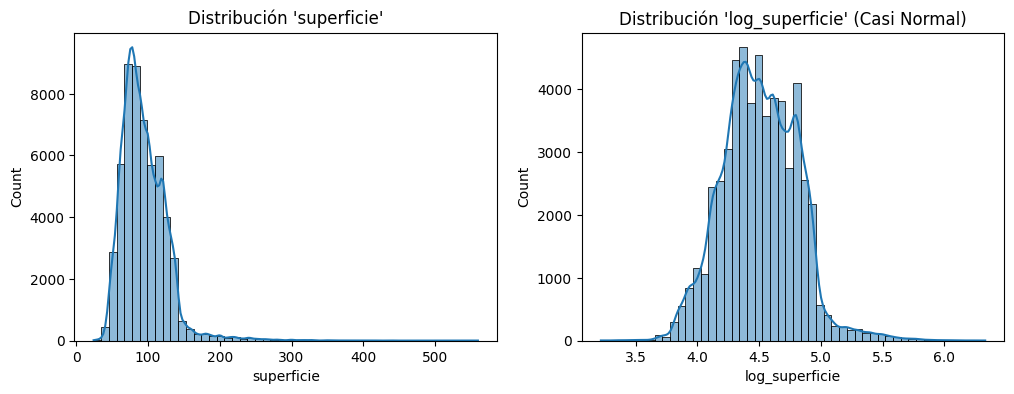

In [ ]:
print("\n--- Creando 'log_superficie' ---")

# 1. Crear log_superficie
# Usamos np.log1p (log(1+x)) por seguridad, aunque ya filtramos superficies > 0
df['log_superficie'] = np.log1p(df['superficie'])

print("Variable 'log_superficie' creada.")

# 2. Comparar la distribución de ambas
print("\nComparación de 'superficie' vs 'log_superficie' (Estadísticos):")
print(df[['superficie', 'log_superficie']].describe())

# 3. Visualizar la transformación (Opcional pero recomendado)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['superficie'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribución 'superficie'")
sns.histplot(df['log_superficie'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribución 'log_superficie' (Casi Normal)")
plt.show()

In [ ]:
# Guardar el DataFrame final, listo para la correlación y el modelado
file_name = "venta_ready.csv"
df.to_csv(file_name, index=False)

print(f"\n¡Éxito! Dataset final guardado como: '{file_name}'")
print(f"Forma final del DataFrame listo para el modelo: {df.shape}")


¡Éxito! Dataset final guardado como: 'venta_ready.csv'
Forma final del DataFrame listo para el modelo: (54770, 39)
